In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

       Дата  Склад Контрагент Номенклатура  Количество
0  1/4/2018      1  address_0    product_0           4
1  1/4/2018      1  address_0    product_1           4
2  1/4/2018      1  address_0    product_2           5
3  1/4/2018      1  address_0    product_3          10
4  1/4/2018      1  address_0    product_4           2


In [43]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Проверяем формат столбцов

In [44]:
df["Дата"] = pd.to_datetime(df["Дата"])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB
None


Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [45]:
grouped_df = df.groupby("Дата")["Количество"].sum().reset_index()
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Вывести несколько первых строк сгруппированных данных

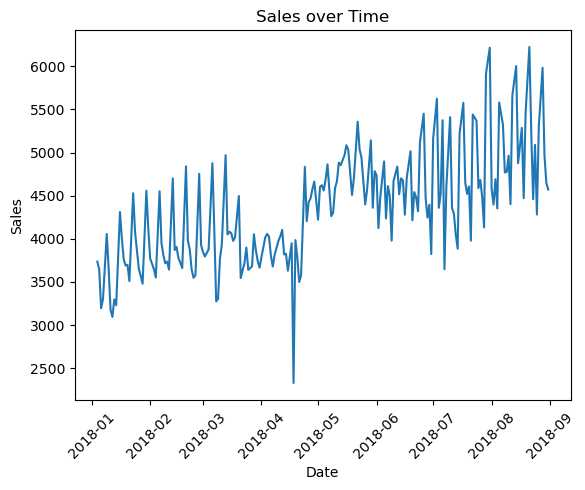

In [46]:
plt.plot(grouped_df["Дата"], grouped_df["Количество"])
plt.title("Sales over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation = 45)
plt.show()

Нарисуйте график продаж у `grouped_df`

In [ ]:
# В целом тренд растущий, если сравнивать начало и конец периода 
# При этом колебания очень значительные, что показывает регулярные изменения в спросе ежедневно, может понедельно 
# Также можно заметить очень резкое падение продаж в апреле, выглядит как выброс 
# Во второй половине периода колебания становятся еще значительнее с большими разбросами, но продолжают расти к концу периода 
# В целом рост устойчивый с течением времени, но сопровождаются регулярными колебаниями и единичными выбросами 

Опишите что вы видите на графике. Ваша задача - максимально описать график

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [47]:
Q1 = df["Количество"].quantile(0.25)
Q3 = df["Количество"].quantile(0.75)
IQR = Q3 - Q1

ul = Q3 + 1.5 * IQR
ll = Q1 - 1.5 * IQR

outliers = df[(df["Количество"] < ll) | (df["Количество"] > ul)].copy()

median = df["Количество"].median()
outliers["distance"] = abs(outliers["Количество"] - median)

max_outlier = outliers.loc[outliers["distance"].idxmax()]

print(max_outlier)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
distance                      198.0
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [48]:
df_new = df[df["Дата"].dt.month.isin([6,7,8])]
df_new = df_new[df_new["Дата"].dt.day_name() == "Wednesday"]
top_3_wh = df["Склад"].unique()[:3]
df_new = df_new[df_new["Склад"].isin(top_3_wh)]

result = (df_new.groupby("Номенклатура")["Количество"].sum().sort_values(ascending = False))
top_product = result.head(1)

print(top_product)

Номенклатура
product_1    8135
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [61]:
weather = pd.read_csv(
    "35188.04.01.2018.31.08.2018.1.0.0.ru.utf8.00000000.csv.gz",
    sep=';',
    encoding='utf-8',
    engine='python',
    on_bad_lines='skip',
    comment='#'
)
weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,70 – 80%.,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,100%.,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [62]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1918 entries, 31.08.2018 23:00 to 04.01.2018 02:00
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Местное время в Астане  1918 non-null   float64
 1   T                       1918 non-null   float64
 2   Po                      1918 non-null   float64
 3   P                       1915 non-null   float64
 4   Pa                      1917 non-null   float64
 5   U                       1918 non-null   object 
 6   DD                      1918 non-null   int64  
 7   Ff                      15 non-null     float64
 8   ff10                    51 non-null     float64
 9   ff3                     1916 non-null   object 
 10  N                       1918 non-null   object 
 11  WW                      689 non-null    object 
 12  W1                      689 non-null    object 
 13  W2                      240 non-null    float64
 14  Tn                

In [63]:
weather = weather[['T']].reset_index()
weather.columns = ['Дата', 'Т']
weather.head()

,Дата,Т
0,31.08.2018 23:00,736.6
1,31.08.2018 20:00,736.4
2,31.08.2018 17:00,735.2
3,31.08.2018 14:00,734.8
4,31.08.2018 11:00,733.9


In [64]:
weather["Дата"] = pd.to_datetime(weather["Дата"], dayfirst=True)
weather["Дата"] = weather["Дата"].dt.date

In [65]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Дата    1918 non-null   object 
 1   Т       1918 non-null   float64
dtypes: float64(1), object(1)
memory usage: 30.1+ KB


In [66]:
daily_average = weather.groupby("Дата", as_index=False)["Т"].mean()
daily_average["Дата"] = pd.to_datetime(daily_average["Дата"])
daily_average.head()

,Дата,Т
0,2018-01-04,744.6625
1,2018-01-05,745.3000
2,2018-01-06,744.2500
3,2018-01-07,742.2375
4,2018-01-08,737.2625


In [67]:
combined_df = pd.merge(grouped_df, daily_average, on = "Дата", how = "left")
combined_df.head()

,Дата,Количество,Т
0,2018-01-04,3734,744.6625
1,2018-01-05,3643,745.3000
2,2018-01-06,3193,744.2500
3,2018-01-07,3298,742.2375
4,2018-01-09,4055,734.1875


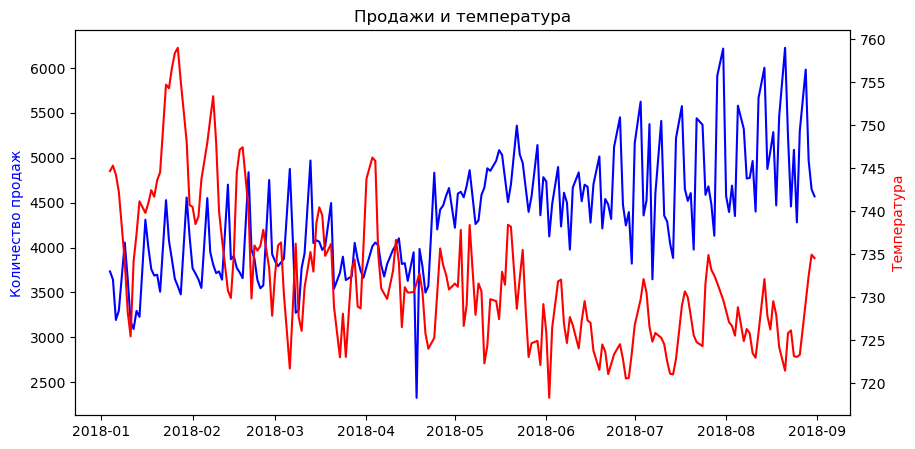

In [70]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(combined_df["Дата"], combined_df["Количество"], color="blue")
ax1.set_ylabel("Количество продаж", color="blue")

ax2 = ax1.twinx()
ax2.plot(combined_df["Дата"], combined_df["Т"], color="red")
ax2.set_ylabel("Температура", color="red")

plt.title("Продажи и температура")
plt.xticks(rotation=45)
plt.show()

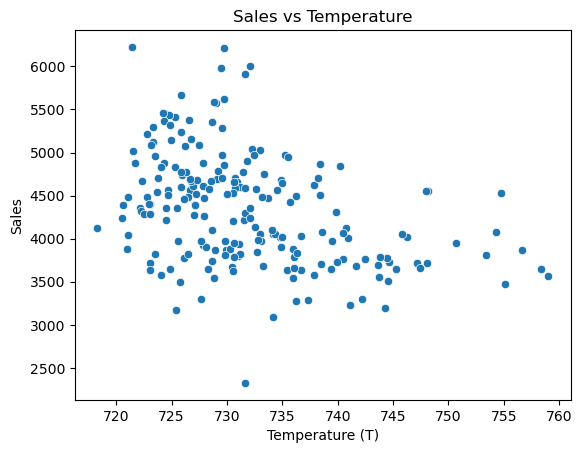

In [73]:
sns.scatterplot(data=combined_df, x="Т", y="Количество")

plt.title("Sales vs Temperature")
plt.xlabel("Temperature (T)")
plt.ylabel("Sales")

plt.show()

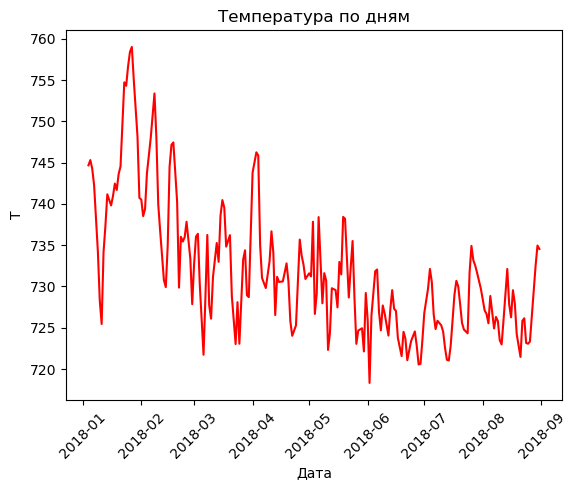

In [71]:
plt.plot(combined_df["Дата"], combined_df["Т"], color="red")
plt.title("Температура по дням")
plt.xlabel("Дата")
plt.ylabel("Т")
plt.xticks(rotation=45)
plt.show()